In [1]:
# importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# LOading the data sets
df_movies = pd.read_csv('../data/movies.csv')

In [3]:
df_ratings = pd.read_csv('../data/ratings.csv')

# Basic Exploration

In [4]:
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
df_movies.shape

(9742, 3)

In [7]:
df_ratings.shape

(100836, 4)

In [8]:
# Finding Missing Values
df_movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [9]:
df_ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [10]:
# checking the dtypes
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [11]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [12]:
df_movies.describe()

,movieId
count,9742.000000
mean,42200.353623
std,52160.494854
min,1.000000
25%,3248.250000
50%,7300.000000
75%,76232.000000
max,193609.000000


In [13]:
df_ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [14]:
# Shape of dataset
print(df_movies.shape)
print(df_ratings.shape)

# Basic info
print(df_movies.info())
print(df_ratings.info())

# Unique values
print("Unique users:", df_ratings['userId'].nunique())
print("Unique movies:", df_ratings['movieId'].nunique())
print("Rating distribution:")
print(df_ratings['rating'].value_counts())

# Sparsity check
total_possible = df_ratings['userId'].nunique() * df_ratings['movieId'].nunique()
actual_ratings = len(df_ratings)
sparsity = 1 - (actual_ratings / total_possible)
print(f"Sparsity: {sparsity:.2%}")

(9742, 3)
(100836, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
Unique users: 610
Unique movies: 9724
Rating distribution:
rating
4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: count, dtype: int

In [15]:
print(df_ratings['rating'].value_counts().sort_index())

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


In [16]:
all_genres = df_movies["genres"].str.split("|")

import itertools
flat = list(itertools.chain.from_iterable(all_genres))
unique_genres = set(flat)
print(unique_genres)
print(len(unique_genres))

{'(no genres listed)', 'Drama', 'Action', 'Mystery', 'Comedy', 'Western', 'Animation', 'Thriller', 'Romance', 'Adventure', 'IMAX', 'War', 'Musical', 'Fantasy', 'Horror', 'Film-Noir', 'Crime', 'Sci-Fi', 'Children', 'Documentary'}
20


In [17]:
# Check Dead Fury's actual genres
df_movies[df_movies['title'].str.contains('Dead Fury')]

,movieId,title,genres
6851,62008,Dead Fury (2008),Action|Animation|Comedy|Horror


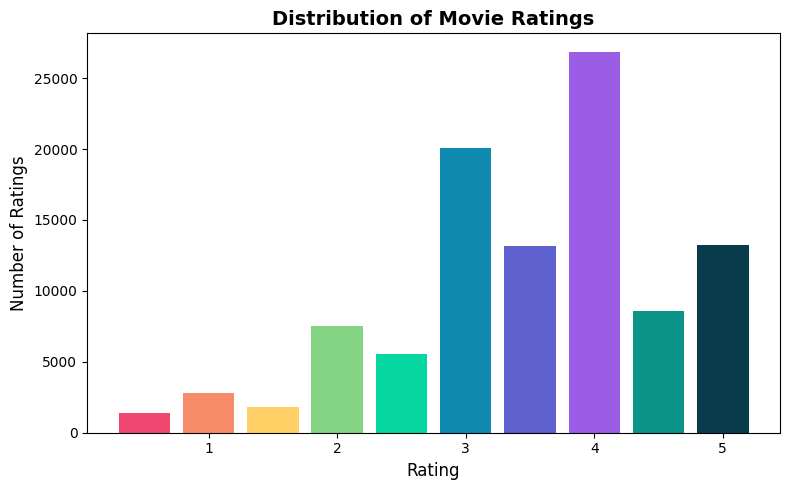

In [18]:
# Count each rating value
rating_counts = df_ratings['rating'].value_counts().sort_index()

# A list of colors — one for each bar
colors = [
    '#EF476F',  # pinkish red
    '#F78C6B',  # coral
    '#FFD166',  # yellow
    '#83D483',  # light green
    '#06D6A0',  # teal green
    '#118AB2',  # blue
    '#5E60CE',  # purple
    '#9B5DE5',  # violet
    '#0D9488',  # dark teal
    '#073B4C',  # navy
]

# Make the chart
plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, 
        color=colors, width=0.4)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Ratings', fontsize=12)
plt.title('Distribution of Movie Ratings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/rating_distribution.png', dpi=150)
plt.show()

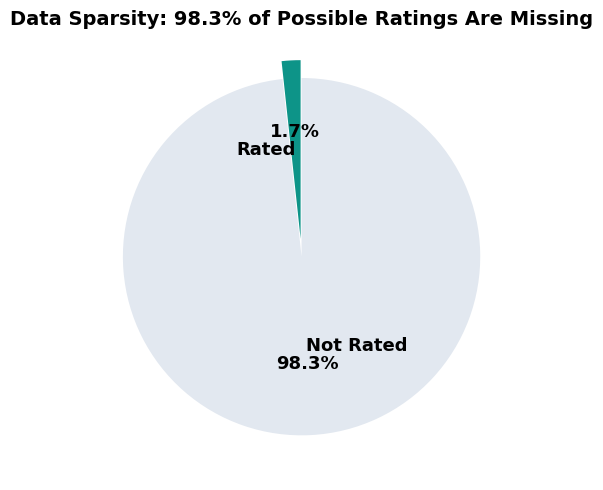

In [19]:
# The two parts
labels = ['Rated', 'Not Rated']
sizes = [1.7, 98.3]
colors = ['#0D9488', '#E2E8F0'] 
explode = (0.1, 0)  # pull out the small slice to highlight it

# Make the pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, colors=colors, explode=explode,autopct='%1.1f%%', labeldistance=0.5, startangle=90,textprops={'fontsize': 13, 'fontweight': 'bold'})
plt.title('Data Sparsity: 98.3% of Possible Ratings Are Missing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/sparsity.png', dpi=150)
plt.show()

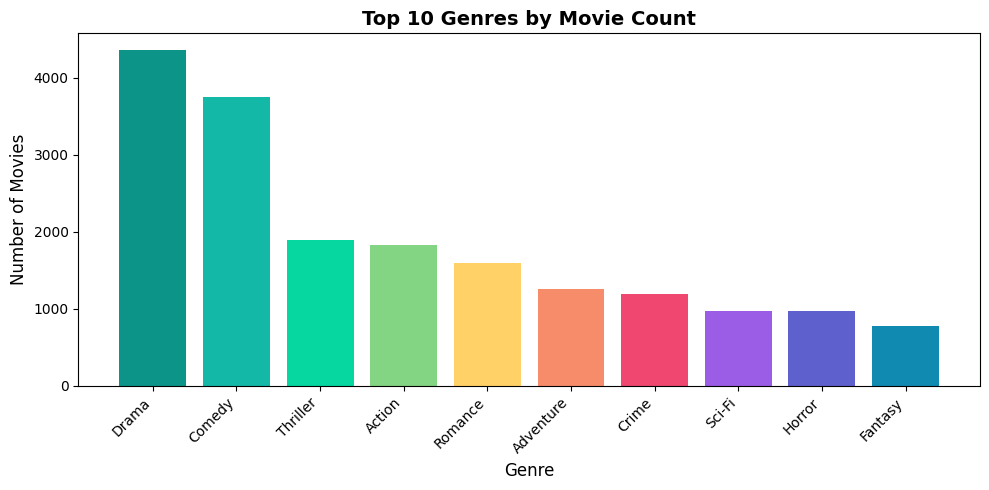

In [20]:
# Genres are pipe-separated (e.g. "Action|Comedy")
# Split them and count each genre
all_genres = df_movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts().head(10)  # top 10

# A list of colors
colors = ['#0D9488', '#14B8A6', '#06D6A0', '#83D483', '#FFD166',
          '#F78C6B', '#EF476F', '#9B5DE5', '#5E60CE', '#118AB2']

# Make the chart
plt.figure(figsize=(10, 5))
plt.bar(genre_counts.index, genre_counts.values, color=colors)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.title('Top 10 Genres by Movie Count', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')  # tilt labels so they fit
plt.tight_layout()
plt.savefig('../images/genre_distribution.png', dpi=150)
plt.show()


In [21]:
# MovieLens titles usually end with "(YYYY)"
years = df_movies['title'].str.extract(r'\((\d{4})\)')[0]
years = pd.to_numeric(years, errors='coerce')

print("Earliest year:", years.min())
print("Latest year:", years.max())
print("\nMovies per year (last 10 years in the data):")
print(years.value_counts().sort_index().tail(10))

Earliest year: 1902.0
Latest year: 2018.0

Movies per year (last 10 years in the data):
0
2009.0    282
2010.0    247
2011.0    254
2012.0    233
2013.0    239
2014.0    278
2015.0    274
2016.0    218
2017.0    147
2018.0     41
Name: count, dtype: int64


In [22]:
# MovieLens doesn't have a language column directly, but we can check
# for likely Indian titles via known Hindi/regional actor or title patterns
# — imperfect, but revealing
indian_hints = df_movies[df_movies['title'].str.contains(
    'Bollywood|Devdas|Lagaan|Sholay|Dilwale|Kabhi|Mohabbat', case=False, na=False)]
print(len(indian_hints))
print(indian_hints['title'].head(10))

df_tags = pd.read_csv("../data/tags.csv")
# Also check the genres/tags file for any language-related tags
print(df_tags['tag'].str.contains('hindi|bollywood|tamil|indian', case=False, na=False).sum() if 'df_tags' in dir() else "no tags loaded")

2
4520                  Bollywood/Hollywood (2002)
4561    Lagaan: Once Upon a Time in India (2001)
Name: title, dtype: object
3
